# 五个癌种 L2 交并集 + Lung 怎么并进去

**Pan-cancer L2 核心 = BRCA ∪ HCC ∪ PDAC ∪ GIST ∪ GBM（17 类）。**

Lung 分两步：

1. **能并的并进核心**：气道上皮 → `Epithelial`，稳态 FB → `Fibroblast`，T/B/DC/巨噬/粒/内皮同义词 → 对应核心类
2. **独有的单独加，但只加粗类**：`Alveolar`、`Injury_epithelial`、`Myofibroblast`（不拆 AT1 vs AT2、RASC vs KRT5、四种 FB）

全局训练表 = **17 + 3 = 20**。`celltype.l2_scope`：`core_5union` / `lung_unique`。细表是 `celltype_fine`。

数据：[`PanCancerCellType.xlsx`](PanCancerCellType.xlsx) 各癌种 sheet 的 pan-cancer L2（去掉 `Other`）。总表是 sheet `celltype`，细表是 `celltype_fine`。
五圆 Venn 不可读，下面用 presence 热图、3-set / 2-set Venn、UpSet。

**Xenium CRC** 已并进同一 20 类（不新开 L2），结果在文末 **§9**。


In [1]:
from pathlib import Path
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj.to_string() if hasattr(obj, "to_string") else obj)
from matplotlib_venn import venn2, venn3

HERE = Path(".").resolve()
if not (HERE / "PanCancerCellType.xlsx").exists():
    HERE = Path("/home/lingyu/ssd2/Python/Hist2Pheno/code/Hist2Pheno_pkg/dataset")
XLSX = HERE / "PanCancerCellType.xlsx"
FIG = HERE / "figures_l2_overlap"
FIG.mkdir(exist_ok=True)

FIVE = ["BRCA", "HCC", "PDAC", "GIST", "GBM"]
ALL6 = ["Lung"] + FIVE
COLORS = {
    "Lung": "#7f8c8d",
    "BRCA": "#c0392b",
    "HCC": "#d35400",
    "PDAC": "#1e8449",
    "GIST": "#2471a3",
    "GBM": "#6c3483",
}

# Lung-unique extras (coarse). Counterfactual: force them into the 5-union.
LUNG_UNIQUE = {"Alveolar", "Injury_epithelial", "Myofibroblast"}
MERGE_INTO_CORE = {
    "Alveolar": "Epithelial",
    "Injury_epithelial": "Epithelial",
    "Myofibroblast": "Fibroblast",
}

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print(XLSX, "exists=", XLSX.exists())


/nobackup2/users/lingyu/Python/Hist2Pheno/code/Hist2Pheno_pkg/dataset/PanCancerCellType.xlsx exists= True


## 1. 读表，构造每个 dataset 的 L2 集合


In [2]:
def trainable_l2(df: pd.DataFrame, col: str = "L2_v1") -> set[str]:
    mask = df.get("trainable_v1", "Y") == "Y"
    vals = df.loc[mask, col].dropna().astype(str).str.strip()
    return {v for v in vals if v and v not in {"Other", "nan"}}


def native_trainable_l2(df: pd.DataFrame) -> set[str]:
    mask = df.get("trainable", "Y") == "Y"
    vals = df.loc[mask, "L2"].dropna().astype(str).str.strip()
    return {v for v in vals if v and v not in {"Other", "nan"}}


sheets = {name: pd.read_excel(XLSX, name) for name in ALL6}
sets_l2 = {name: trainable_l2(sheets[name]) for name in ALL6}
sets_native = {name: native_trainable_l2(sheets[name]) for name in ALL6}

lung_merged = {MERGE_INTO_CORE.get(x, x) for x in sets_l2["Lung"]}
sets_merged = dict(sets_l2)
sets_merged["Lung"] = lung_merged

count_tbl = pd.DataFrame({
    "dataset": ALL6,
    "native_L2": [len(sets_native[n]) for n in ALL6],
    "L2": [len(sets_l2[n]) for n in ALL6],
    "L2_if_no_lung_extras": [len(sets_merged[n]) for n in ALL6],
})
display(count_tbl)

print("L2 集合（核心 + Lung 粗类 extras）:")
for n in ALL6:
    print(f"  {n:5s} ({len(sets_l2[n]):2d}): {sorted(sets_l2[n])}")
print("Lung extras:", sorted(sets_l2["Lung"] & LUNG_UNIQUE))
print("Lung after merge-into-core only:", sorted(lung_merged))


,dataset,native_L2,L2,L2_if_no_lung_extras
0,Lung,39,16,13
1,BRCA,12,11,11
2,HCC,12,11,11
3,PDAC,11,10,10
4,GIST,11,10,10
5,GBM,12,7,7


L2 集合（核心 + Lung 粗类 extras）:
  Lung  (16): ['Alveolar', 'B_cell', 'CD4_T', 'CD8_T', 'DC', 'Endothelial', 'Epithelial', 'Fibroblast', 'Injury_epithelial', 'Macrophage', 'Macrophage_activated', 'Myofibroblast', 'Neutrophil', 'Plasma', 'Stromal', 'T_cell']
  BRCA  (11): ['B_cell', 'CD4_T', 'CD8_T', 'DC', 'DCIS', 'Endothelial', 'Macrophage', 'Myoepithelial', 'Neutrophil', 'Stromal', 'Tumor']
  HCC   (11): ['B_cell', 'CD4_T', 'CD8_T', 'DC', 'Endothelial', 'Fibroblast', 'Macrophage', 'Macrophage_activated', 'Neutrophil', 'T_cell', 'Tumor']
  PDAC  (10): ['B_cell', 'CD4_T', 'CD8_T', 'DC', 'Endothelial', 'Epithelial', 'Fibroblast', 'Macrophage', 'Neutrophil', 'Plasma']
  GIST  (10): ['B_cell', 'CD4_T', 'DC', 'Endothelial', 'Epithelial', 'Fibroblast', 'Macrophage', 'Neutrophil', 'Stromal', 'T_cell']
  GBM   ( 7): ['Endothelial', 'Macrophage', 'Macrophage_activated', 'Neural', 'Stromal', 'T_cell', 'Tumor']
Lung extras: ['Alveolar', 'Injury_epithelial', 'Myofibroblast']
Lung after merge-into-core 

## 2. 五癌种交并集

- **5 交集**：所有 5 个 dataset 都有的类（通常很少，因为 GBM 没有淋巴细胞细分、PDAC/GIST 没有 Tumor 头）
- **5 并集**：这就是五癌并集，也是 pan-cancer L2 核心（17 类）
- **k-way**：恰好出现在 k 个 dataset 的类


In [3]:
def set_stats(sets: dict[str, set[str]], names: list[str]) -> dict:
    vals = [sets[n] for n in names]
    union = set.union(*vals)
    inter = set.intersection(*vals)
    return {"union": union, "intersect": inter}


five = set_stats(sets_l2, FIVE)
five_native = set_stats(sets_native, FIVE)
lung_only_merged = lung_merged - five["union"]
lung_only_extras = sets_l2["Lung"] - five["union"]
five_not_in_lung = five["union"] - sets_l2["Lung"]

print(f"L2  5-union      ({len(five['union']):2d}): {sorted(five['union'])}")
print(f"L2  5-intersect  ({len(five['intersect']):2d}): {sorted(five['intersect'])}")
print(f"native 5-union   ({len(five_native['union']):2d})")
print(f"native 5-intersect ({len(five_native['intersect']):2d}): {sorted(five_native['intersect'])}")
print(f"Lung-only if merge-into-core: {sorted(lung_only_merged)}")
print(f"Lung-only extras (kept):      {sorted(lung_only_extras)}")
print(f"5-union 但不在 Lung: {sorted(five_not_in_lung)}")

presence = pd.DataFrame(
    {ds: [int(lab in sets_l2[ds]) for lab in sorted(five["union"])] for ds in FIVE},
    index=sorted(five["union"]),
)
presence["n_datasets"] = presence.sum(axis=1)
presence = presence.sort_values(["n_datasets"] + FIVE, ascending=[False] + [False] * 5)
display(presence)

print("\n恰好出现在 k 个 dataset:")
for k, grp in presence.groupby("n_datasets"):
    print(f"  k={k} ({len(grp)}): {list(grp.index)}")


L2  5-union      (17): ['B_cell', 'CD4_T', 'CD8_T', 'DC', 'DCIS', 'Endothelial', 'Epithelial', 'Fibroblast', 'Macrophage', 'Macrophage_activated', 'Myoepithelial', 'Neural', 'Neutrophil', 'Plasma', 'Stromal', 'T_cell', 'Tumor']
L2  5-intersect  ( 2): ['Endothelial', 'Macrophage']
native 5-union   (33)
native 5-intersect ( 0): []
Lung-only if merge-into-core: []
Lung-only extras (kept):      ['Alveolar', 'Injury_epithelial', 'Myofibroblast']
5-union 但不在 Lung: ['DCIS', 'Myoepithelial', 'Neural', 'Tumor']


,BRCA,HCC,PDAC,GIST,GBM,n_datasets
Endothelial,1,1,1,1,1,5
Macrophage,1,1,1,1,1,5
B_cell,1,1,1,1,0,4
CD4_T,1,1,1,1,0,4
DC,1,1,1,1,0,4
Neutrophil,1,1,1,1,0,4
CD8_T,1,1,1,0,0,3
Tumor,1,1,0,0,1,3
Stromal,1,0,0,1,1,3
Fibroblast,0,1,1,1,0,3



恰好出现在 k 个 dataset:
  k=1 (4): ['DCIS', 'Myoepithelial', 'Plasma', 'Neural']
  k=2 (2): ['Macrophage_activated', 'Epithelial']
  k=3 (5): ['CD8_T', 'Tumor', 'Stromal', 'Fibroblast', 'T_cell']
  k=4 (4): ['B_cell', 'CD4_T', 'DC', 'Neutrophil']
  k=5 (2): ['Endothelial', 'Macrophage']


## 3. Presence 热图

左：五癌 17 类核心。右：加上 Lung 后的 20 类（`celltype`：17 core + 3 extras）。


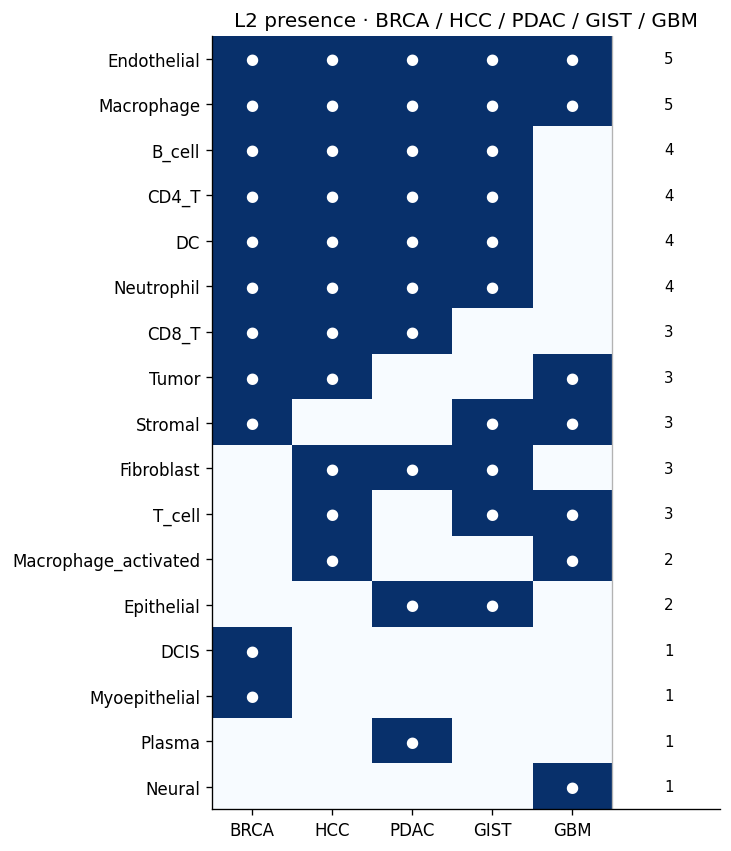

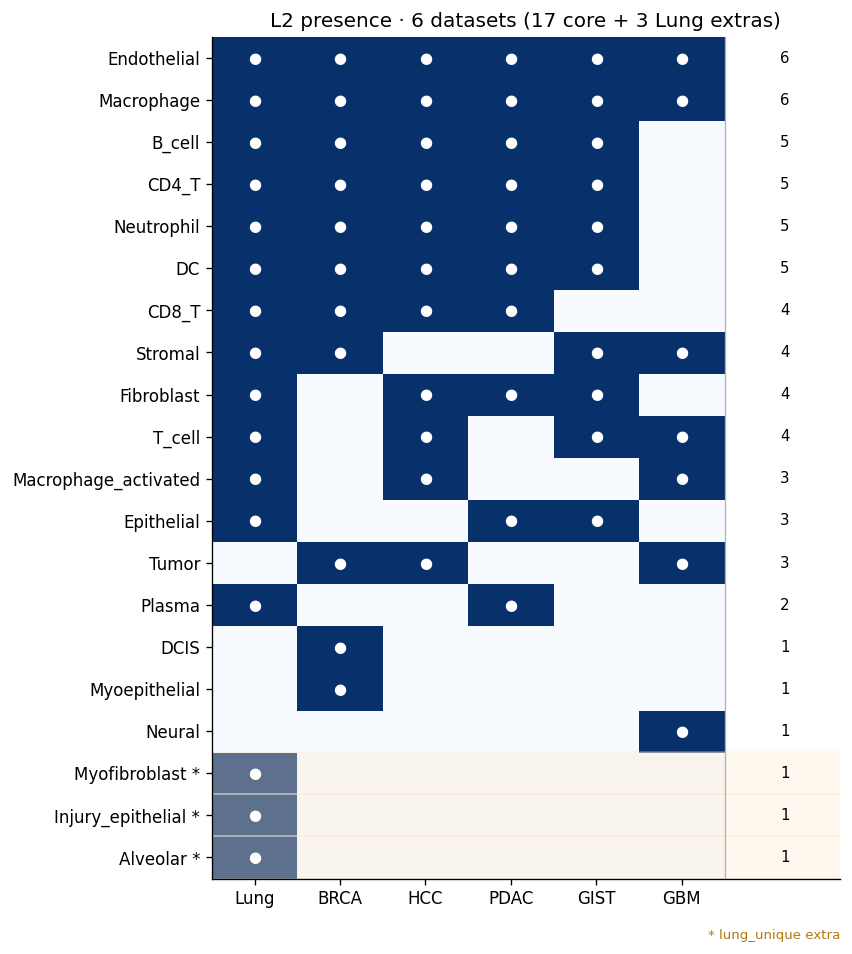

,Lung,BRCA,HCC,PDAC,GIST,GBM,n_datasets
Endothelial,1,1,1,1,1,1,6
Macrophage,1,1,1,1,1,1,6
B_cell,1,1,1,1,1,0,5
CD4_T,1,1,1,1,1,0,5
Neutrophil,1,1,1,1,1,0,5
DC,1,1,1,1,1,0,5
CD8_T,1,1,1,1,0,0,4
Stromal,1,1,0,0,1,1,4
Fibroblast,1,0,1,1,1,0,4
T_cell,1,0,1,0,1,1,4


In [4]:
def _presence_heatmap(ax, df, datasets, title, extra_rows=None):
    mat = df[datasets].to_numpy()
    ax.imshow(mat, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(datasets)))
    ax.set_xticklabels(datasets)
    ylabels = []
    for lab in df.index:
        ylabels.append(f"{lab} *" if extra_rows and lab in extra_rows else lab)
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(ylabels)
    ax.set_title(title)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, "●" if mat[i, j] else "", ha="center", va="center", color="white", fontsize=9)
        ax.text(len(datasets) + 0.15, i, str(int(df.iloc[i]["n_datasets"])), va="center", fontsize=9)
        if extra_rows and df.index[i] in extra_rows:
            ax.axhspan(i - 0.5, i + 0.5, color="#fdebd0", alpha=0.35, zorder=0)
    ax.set_xlim(-0.5, len(datasets) + 0.85)
    ax.axvline(len(datasets) - 0.5, color="0.7", lw=0.8)


fig, ax = plt.subplots(figsize=(6.2, 7.2))
_presence_heatmap(ax, presence, FIVE, "L2 presence · BRCA / HCC / PDAC / GIST / GBM")
fig.tight_layout()
fig.savefig(FIG / "01_presence_heatmap_5datasets.png", bbox_inches="tight")
plt.show()

labels20 = list(five["union"] | LUNG_UNIQUE)
presence6 = pd.DataFrame(
    {ds: [int(lab in sets_l2[ds]) for lab in labels20] for ds in ALL6},
    index=labels20,
)
presence6["n_datasets"] = presence6[ALL6].sum(axis=1)
presence6["is_extra"] = [lab in LUNG_UNIQUE for lab in presence6.index]
presence6 = presence6.sort_values(
    ["is_extra", "n_datasets"] + ALL6, ascending=[True, False] + [False] * len(ALL6)
)

fig, ax = plt.subplots(figsize=(7.2, 8.0))
_presence_heatmap(
    ax, presence6, ALL6,
    "L2 presence · 6 datasets (17 core + 3 Lung extras)",
    extra_rows=LUNG_UNIQUE,
)
ax.text(
    1.0, -0.06, "* lung_unique extra",
    transform=ax.transAxes, ha="right", va="top", fontsize=8, color="#b9770e",
)
fig.tight_layout()
fig.savefig(FIG / "01b_presence_heatmap_6datasets.png", bbox_inches="tight")
plt.show()
display(presence6[ALL6 + ["n_datasets"]])


## 4. Venn：实体瘤三联 + GIST 三联

五圆 Venn 标签会叠在一起，所以拆成两组 3-set：

- BRCA ∩ HCC ∩ PDAC（三个上皮癌）
- HCC ∩ PDAC ∩ GIST（三个 CODEX 实体瘤 / TMA）


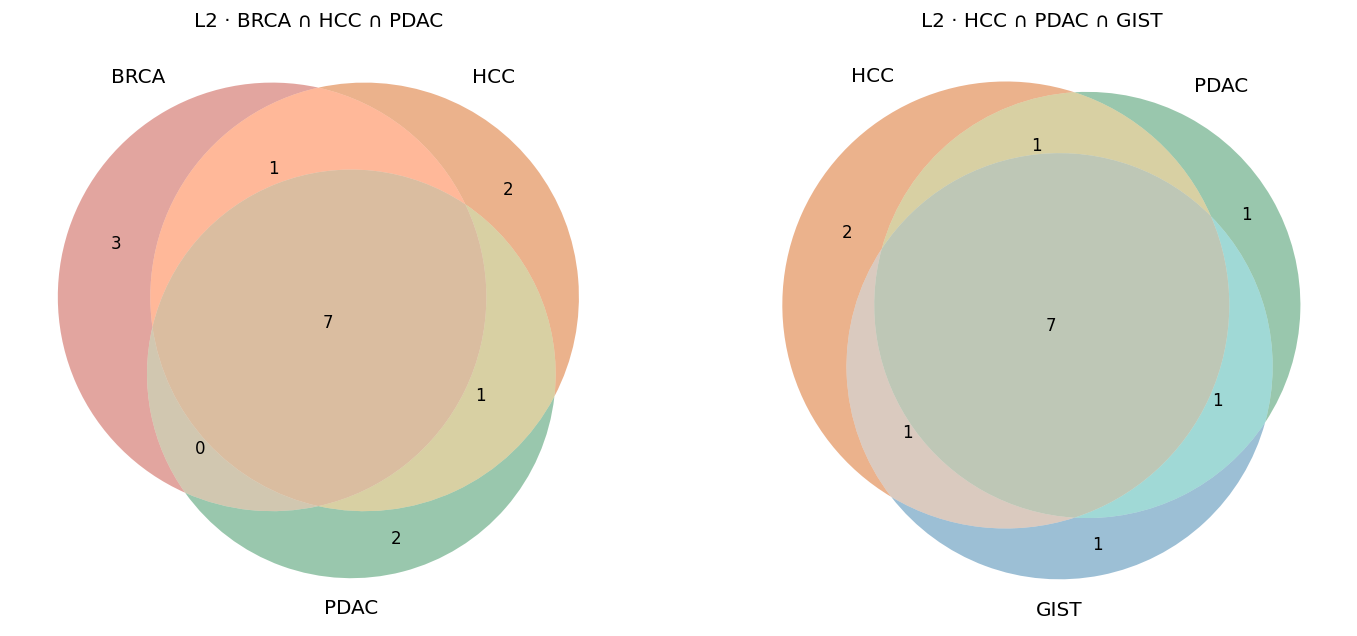

BRCA ∩ HCC ∩ PDAC = ['B_cell', 'CD4_T', 'CD8_T', 'DC', 'Endothelial', 'Macrophage', 'Neutrophil']
HCC ∩ PDAC ∩ GIST = ['B_cell', 'CD4_T', 'DC', 'Endothelial', 'Fibroblast', 'Macrophage', 'Neutrophil']
BRCA only vs HCC∪PDAC: ['DCIS', 'Myoepithelial', 'Stromal']
PDAC only vs HCC∪GIST: ['Plasma']
GIST only vs HCC∪PDAC: ['Stromal']


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12.2, 5.4))
venn3(
    [sets_l2["BRCA"], sets_l2["HCC"], sets_l2["PDAC"]],
    set_labels=("BRCA", "HCC", "PDAC"),
    set_colors=(COLORS["BRCA"], COLORS["HCC"], COLORS["PDAC"]),
    alpha=0.45,
    ax=axes[0],
)
axes[0].set_title("L2 · BRCA ∩ HCC ∩ PDAC")
venn3(
    [sets_l2["HCC"], sets_l2["PDAC"], sets_l2["GIST"]],
    set_labels=("HCC", "PDAC", "GIST"),
    set_colors=(COLORS["HCC"], COLORS["PDAC"], COLORS["GIST"]),
    alpha=0.45,
    ax=axes[1],
)
axes[1].set_title("L2 · HCC ∩ PDAC ∩ GIST")
fig.tight_layout()
fig.savefig(FIG / "02_venn3_triplets.png", bbox_inches="tight")
plt.show()

print("BRCA ∩ HCC ∩ PDAC =", sorted(sets_l2["BRCA"] & sets_l2["HCC"] & sets_l2["PDAC"]))
print("HCC ∩ PDAC ∩ GIST =", sorted(sets_l2["HCC"] & sets_l2["PDAC"] & sets_l2["GIST"]))
print("BRCA only vs HCC∪PDAC:", sorted(sets_l2["BRCA"] - (sets_l2["HCC"] | sets_l2["PDAC"])))
print("PDAC only vs HCC∪GIST:", sorted(sets_l2["PDAC"] - (sets_l2["HCC"] | sets_l2["GIST"])))
print("GIST only vs HCC∪PDAC:", sorted(sets_l2["GIST"] - (sets_l2["HCC"] | sets_l2["PDAC"])))


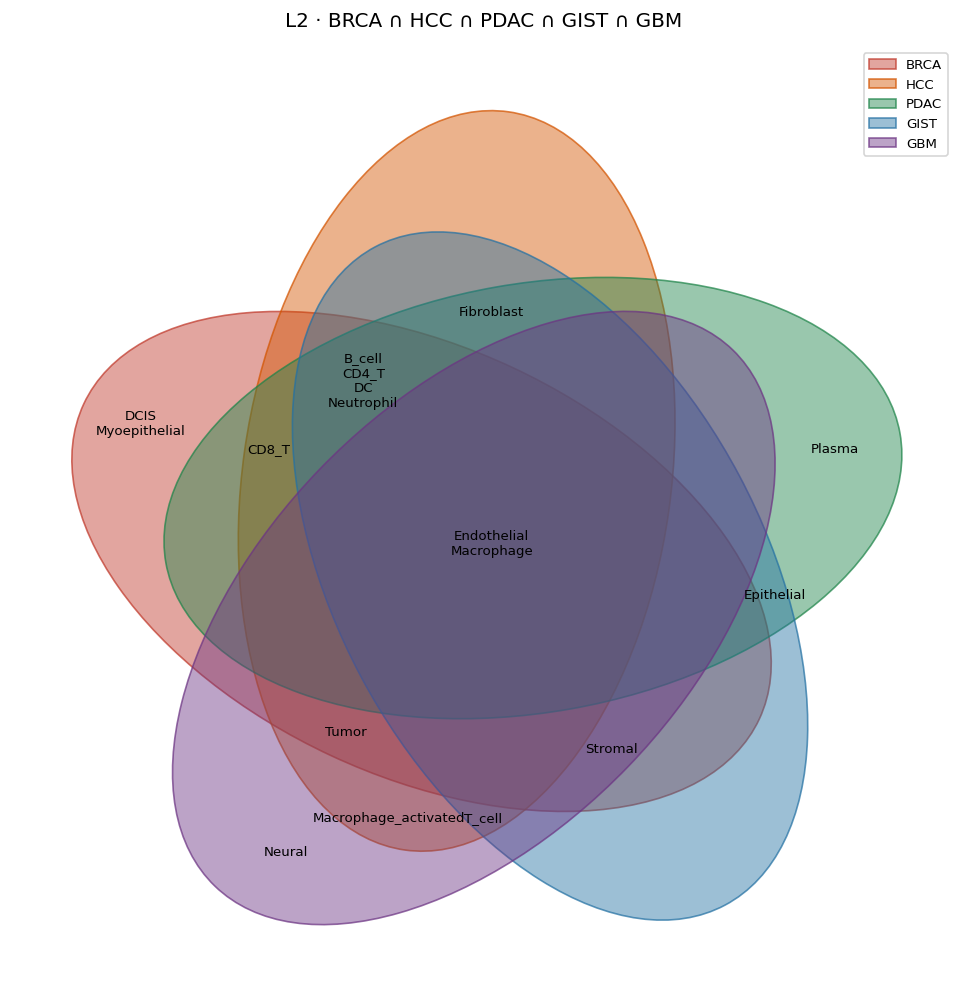

5-union ['B_cell', 'CD4_T', 'CD8_T', 'DC', 'DCIS', 'Endothelial', 'Epithelial', 'Fibroblast', 'Macrophage', 'Macrophage_activated', 'Myoepithelial', 'Neural', 'Neutrophil', 'Plasma', 'Stromal', 'T_cell', 'Tumor']
5-intersect ['Endothelial', 'Macrophage']

  BRCA+HCC+PDAC+GIST+GBM                    Endothelial, Macrophage
  BRCA+HCC+PDAC+GIST                        B_cell, CD4_T, DC, Neutrophil
  HCC+GIST+GBM                              T_cell
  HCC+PDAC+GIST                             Fibroblast
  BRCA+GIST+GBM                             Stromal
  BRCA+HCC+GBM                              Tumor
  BRCA+HCC+PDAC                             CD8_T
  PDAC+GIST                                 Epithelial
  HCC+GBM                                   Macrophage_activated
  GBM                                       Neural
  PDAC                                      Plasma
  BRCA                                      DCIS, Myoepithelial


In [6]:
# 5-dataset Venn (BRCA / HCC / PDAC / GIST / GBM). Empty petals left blank.
from venn import draw_venn, generate_petal_labels

sets5 = [sets_l2[n] for n in FIVE]


def exclusive_for_bits(key: str) -> list[str]:
    inside = [FIVE[i] for i, bit in enumerate(key) if bit == "1"]
    outside = [n for n in FIVE if n not in inside]
    inter = set.intersection(*(sets_l2[n] for n in inside))
    extra = set.union(*(sets_l2[n] for n in outside)) if outside else set()
    return sorted(inter - extra)


petal = {}
for key in generate_petal_labels(sets5):
    names = exclusive_for_bits(key)
    petal[key] = "\n".join(names) if names else ""

rgba = []
for name in FIVE:
    h = COLORS[name].lstrip("#")
    rgba.append(
        [int(h[0:2], 16) / 255, int(h[2:4], 16) / 255, int(h[4:6], 16) / 255, 0.45]
    )

ax = draw_venn(
    petal_labels=petal,
    dataset_labels=FIVE,
    hint_hidden=False,
    colors=rgba,
    figsize=(11.2, 10.2),
    fontsize=8,
    legend_loc="upper right",
    ax=None,
)
ax.set_title("L2 · BRCA ∩ HCC ∩ PDAC ∩ GIST ∩ GBM", pad=12)
fig = ax.figure
fig.savefig(FIG / "02b_venn5_five_datasets.png", bbox_inches="tight")
plt.show()

print("5-union", sorted(set.union(*sets5)))
print("5-intersect", sorted(set.intersection(*sets5)))
print()
for key in sorted(petal, key=lambda k: (-k.count("1"), k)):
    if not petal[key]:
        continue
    members = "+".join(FIVE[i] for i, bit in enumerate(key) if bit == "1")
    print(f"  {members:40s}  {petal[key].replace(chr(10), ', ')}")


## 5. Venn：四个实体瘤 vs GBM；Lung 只并核心 / 加上 3 个粗类 extras


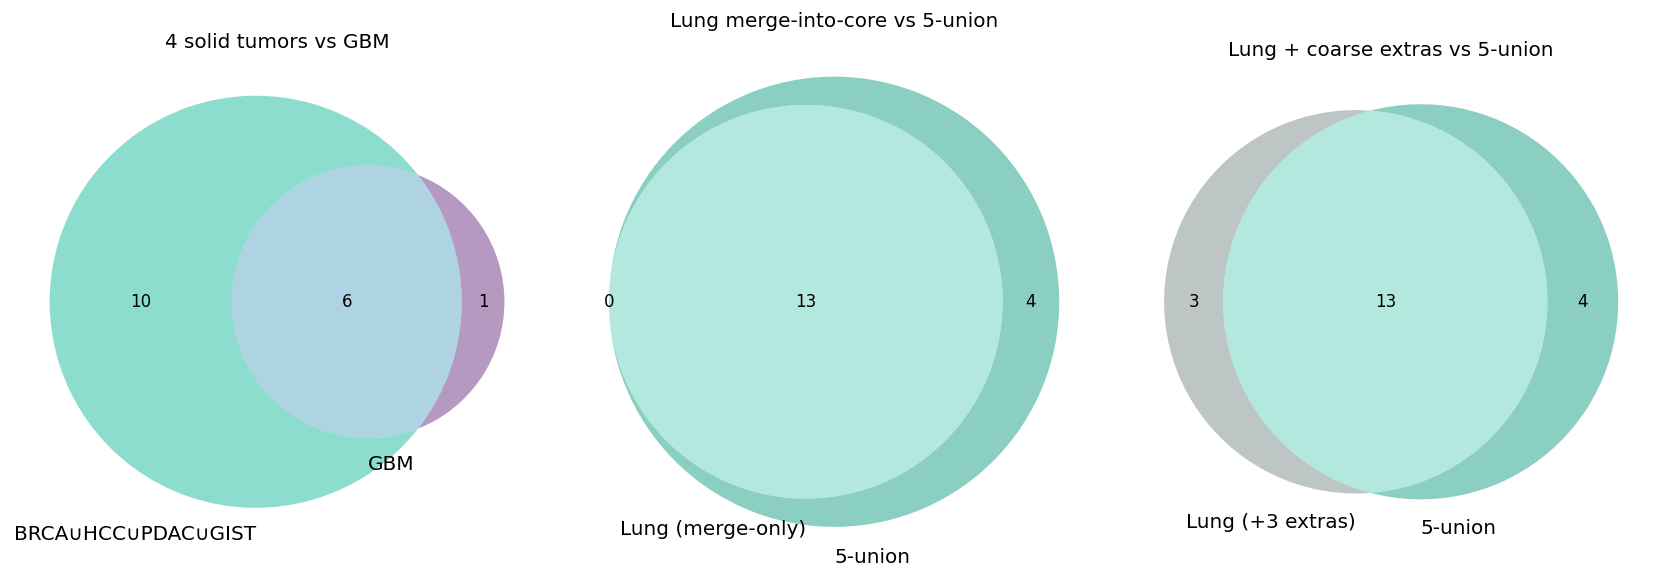

GBM only: ['Neural']
four only vs GBM: ['B_cell', 'CD4_T', 'CD8_T', 'DC', 'DCIS', 'Epithelial', 'Fibroblast', 'Myoepithelial', 'Neutrophil', 'Plasma']
Lung ∩ 5-union (merge-only): ['B_cell', 'CD4_T', 'CD8_T', 'DC', 'Endothelial', 'Epithelial', 'Fibroblast', 'Macrophage', 'Macrophage_activated', 'Neutrophil', 'Plasma', 'Stromal', 'T_cell']
Lung ∩ 5-union (+extras):    ['B_cell', 'CD4_T', 'CD8_T', 'DC', 'Endothelial', 'Epithelial', 'Fibroblast', 'Macrophage', 'Macrophage_activated', 'Neutrophil', 'Plasma', 'Stromal', 'T_cell']
kept extras: ['Alveolar', 'Injury_epithelial', 'Myofibroblast']


In [7]:
four = sets_l2["BRCA"] | sets_l2["HCC"] | sets_l2["PDAC"] | sets_l2["GIST"]
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.8))
venn2(
    [four, sets_l2["GBM"]],
    set_labels=("BRCA∪HCC∪PDAC∪GIST", "GBM"),
    set_colors=("#1abc9c", COLORS["GBM"]),
    alpha=0.5,
    ax=axes[0],
)
axes[0].set_title("4 solid tumors vs GBM")
venn2(
    [lung_merged, five["union"]],
    set_labels=("Lung (merge-only)", "5-union"),
    set_colors=(COLORS["Lung"], "#16a085"),
    alpha=0.5,
    ax=axes[1],
)
axes[1].set_title("Lung merge-into-core vs 5-union")
venn2(
    [sets_l2["Lung"], five["union"]],
    set_labels=("Lung (+3 extras)", "5-union"),
    set_colors=(COLORS["Lung"], "#16a085"),
    alpha=0.5,
    ax=axes[2],
)
axes[2].set_title("Lung + coarse extras vs 5-union")
fig.tight_layout()
fig.savefig(FIG / "03_venn2_gbm_lung.png", bbox_inches="tight")
plt.show()

print("GBM only:", sorted(sets_l2["GBM"] - four))
print("four only vs GBM:", sorted(four - sets_l2["GBM"]))
print("Lung ∩ 5-union (merge-only):", sorted(lung_merged & five["union"]))
print("Lung ∩ 5-union (+extras):   ", sorted(sets_l2["Lung"] & five["union"]))
print("kept extras:", sorted(sets_l2["Lung"] - five["union"]))


## 6. UpSet：五癌种互斥交集

每个柱是「恰好这几个 dataset 共有、且不在其余 dataset」的 L2 个数。


,datasets,n,L2
0,BRCA ∩ HCC ∩ PDAC ∩ GIST,4,"B_cell, CD4_T, DC, Neutrophil"
1,BRCA ∩ HCC ∩ PDAC ∩ GIST ∩ GBM,2,"Endothelial, Macrophage"
2,BRCA,2,"DCIS, Myoepithelial"
3,BRCA ∩ GIST ∩ GBM,1,Stromal
4,BRCA ∩ HCC ∩ GBM,1,Tumor
5,BRCA ∩ HCC ∩ PDAC,1,CD8_T
6,HCC ∩ GIST ∩ GBM,1,T_cell
7,HCC ∩ PDAC ∩ GIST,1,Fibroblast
8,HCC ∩ GBM,1,Macrophage_activated
9,PDAC ∩ GIST,1,Epithelial


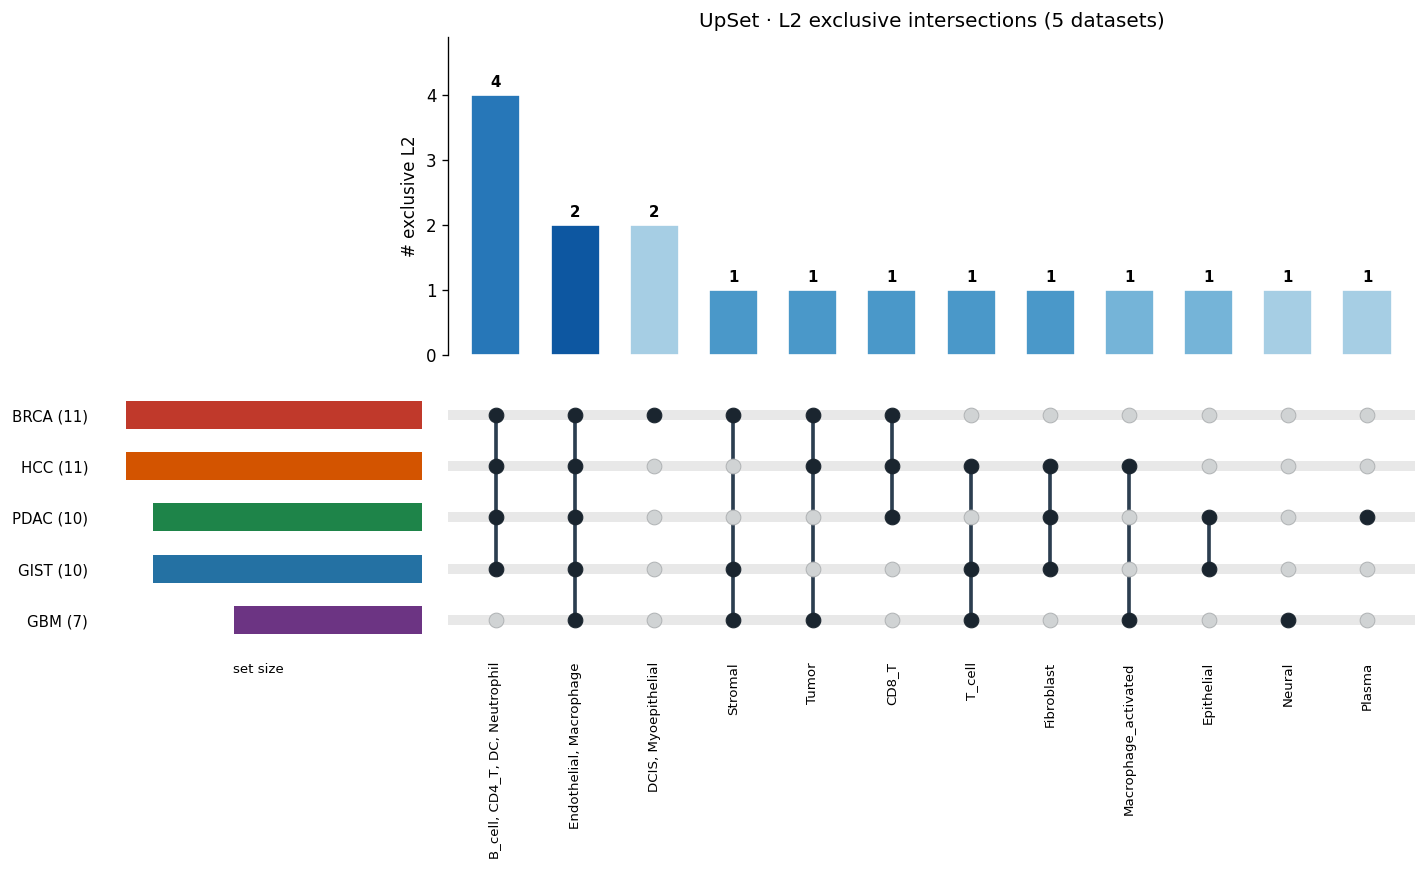

In [8]:
def exclusive_intersections(sets: dict[str, set[str]], names: list[str]):
    rows = []
    for r in range(1, len(names) + 1):
        for comb in combinations(names, r):
            inter = set.intersection(*(sets[n] for n in comb))
            others = [n for n in names if n not in comb]
            extra = set.union(*(sets[n] for n in others)) if others else set()
            excl = inter - extra
            if excl:
                rows.append({"combo": comb, "labels": sorted(excl), "n": len(excl)})
    rows.sort(key=lambda d: (-d["n"], -len(d["combo"]), d["combo"]))
    return rows


upset_rows = exclusive_intersections(sets_l2, FIVE)
upset_df = pd.DataFrame(
    {
        "datasets": [" ∩ ".join(r["combo"]) for r in upset_rows],
        "n": [r["n"] for r in upset_rows],
        "L2": [", ".join(r["labels"]) for r in upset_rows],
    }
)
display(upset_df)

n_bar = len(upset_rows)
xs = np.arange(n_bar)
set_sizes = [len(sets_l2[n]) for n in FIVE]
degree = [len(r["combo"]) for r in upset_rows]
# more datasets in the intersection → darker bar
bar_colors = plt.cm.Blues(np.interp(degree, [1, 5], [0.35, 0.85]))

fig = plt.figure(figsize=(14.2, 8.6))
gs = fig.add_gridspec(
    2, 2,
    width_ratios=[1.7, 5.0],
    height_ratios=[2.3, 2.0],
    wspace=0.04,
    hspace=0.08,
)
ax_bar = fig.add_subplot(gs[0, 1])
ax_mat = fig.add_subplot(gs[1, 1], sharex=ax_bar)
ax_set = fig.add_subplot(gs[1, 0])

ax_bar.bar(xs, [r["n"] for r in upset_rows], color=bar_colors, width=0.62, edgecolor="white")
for i, r in enumerate(upset_rows):
    ax_bar.text(i, r["n"] + 0.08, str(r["n"]), ha="center", va="bottom", fontsize=9, fontweight="bold")
ax_bar.set_ylabel("# exclusive L2")
ax_bar.set_title("UpSet · L2 exclusive intersections (5 datasets)")
ax_bar.set_ylim(0, max(r["n"] for r in upset_rows) + 0.9)
ax_bar.tick_params(axis="x", bottom=False, labelbottom=False)
ax_bar.spines["bottom"].set_visible(False)

# matrix: filled dots + connector (no crowded ∩ names)
for i in range(len(FIVE)):
    ax_mat.axhline(i, color="#e8e8e8", lw=6, zorder=0, solid_capstyle="butt")
for j, r in enumerate(upset_rows):
    idxs = [i for i, name in enumerate(FIVE) if name in r["combo"]]
    if len(idxs) >= 2:
        ax_mat.plot([j, j], [min(idxs), max(idxs)], color="#2c3e50", lw=2.2, zorder=1)
    for i, name in enumerate(FIVE):
        on = name in r["combo"]
        ax_mat.scatter(
            j, i, s=78, zorder=2,
            facecolors="#1a252f" if on else "#d0d3d4",
            edgecolors="#1a252f" if on else "#b0b3b5",
            linewidths=0.6,
        )
ax_mat.set_yticks(range(len(FIVE)))
ax_mat.set_yticklabels([])
ax_mat.set_xticks(xs)
ax_mat.set_xticklabels(
    [", ".join(r["labels"]) for r in upset_rows],
    rotation=90,
    ha="center",
    va="top",
    fontsize=8,
)
ax_mat.set_xlim(-0.6, n_bar - 0.4)
ax_mat.set_ylim(-0.7, len(FIVE) - 0.3)
ax_mat.invert_yaxis()
ax_mat.tick_params(length=0)
for sp in ax_mat.spines.values():
    sp.set_visible(False)

ax_set.barh(range(len(FIVE)), set_sizes, color=[COLORS[n] for n in FIVE], height=0.55)
ax_set.set_yticks(range(len(FIVE)))
ax_set.set_yticklabels([f"{n} ({s})" for n, s in zip(FIVE, set_sizes)], fontsize=9)
ax_set.set_ylim(-0.7, len(FIVE) - 0.3)
ax_set.invert_yaxis()
ax_set.invert_xaxis()
ax_set.set_xlim(max(set_sizes) + 1.2, 0)
ax_set.set_xticks([])
ax_set.set_xlabel("set size", fontsize=8)
ax_set.tick_params(left=False, right=False, labelright=False, length=0)
for sp in ax_set.spines.values():
    sp.set_visible(False)

fig.subplots_adjust(bottom=0.28)
fig.savefig(FIG / "04_upset_5datasets.png", bbox_inches="tight")
plt.show()


## 7. Pairwise Jaccard


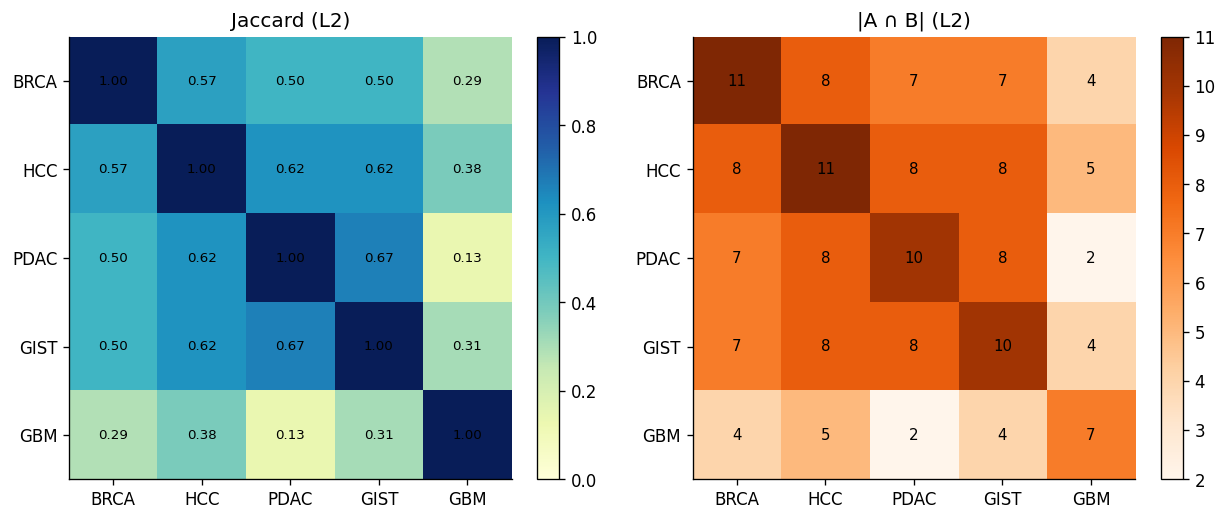

,BRCA,HCC,PDAC,GIST,GBM
BRCA,11,8,7,7,4
HCC,8,11,8,8,5
PDAC,7,8,10,8,2
GIST,7,8,8,10,4
GBM,4,5,2,4,7


In [9]:
jacc = pd.DataFrame(np.nan, index=FIVE, columns=FIVE)
overlap_n = pd.DataFrame(0, index=FIVE, columns=FIVE)
for a, b in combinations(FIVE, 2):
    inter = sets_l2[a] & sets_l2[b]
    uni = sets_l2[a] | sets_l2[b]
    j = len(inter) / len(uni) if uni else 0
    jacc.loc[a, b] = jacc.loc[b, a] = j
    overlap_n.loc[a, b] = overlap_n.loc[b, a] = len(inter)
for a in FIVE:
    jacc.loc[a, a] = 1.0
    overlap_n.loc[a, a] = len(sets_l2[a])

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4))
im0 = axes[0].imshow(jacc.to_numpy(), cmap="YlGnBu", vmin=0, vmax=1)
axes[0].set_xticks(range(5)); axes[0].set_xticklabels(FIVE)
axes[0].set_yticks(range(5)); axes[0].set_yticklabels(FIVE)
axes[0].set_title("Jaccard (L2)")
for i in range(5):
    for j in range(5):
        axes[0].text(j, i, f"{jacc.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im0, ax=axes[0], fraction=0.046)
im1 = axes[1].imshow(overlap_n.to_numpy(), cmap="Oranges")
axes[1].set_xticks(range(5)); axes[1].set_xticklabels(FIVE)
axes[1].set_yticks(range(5)); axes[1].set_yticklabels(FIVE)
axes[1].set_title("|A ∩ B| (L2)")
for i in range(5):
    for j in range(5):
        axes[1].text(j, i, str(int(overlap_n.iloc[i, j])), ha="center", va="center", fontsize=9)
fig.colorbar(im1, ax=axes[1], fraction=0.046)
fig.tight_layout()
fig.savefig(FIG / "05_pairwise_jaccard.png", bbox_inches="tight")
plt.show()
display(overlap_n)


## 8. Lung：能并的并进 17 类核心，独有的只加 3 个粗类

| Lung native（已合并，不单列） | → 核心 L2 |
|------------------------------|-----------|
| Basal / Secretory / Goblet / Multiciliated / PNEC / Prolif Airway / Mesothelial | `Epithelial` |
| Alveolar / Adventitial / Subpleural FBs | `Fibroblast` |
| CD4 / CD8 / Treg / B / Plasma / DC* / Mac* / Neutrophil / Mast / 内皮亚型 | 对应核心类 |

| 独有（粗类 extras） | 收进去的 native | 不拆 |
|---------------------|-----------------|------|
| `Alveolar` | AT1, AT2, Proliferating AT2 | 不拆 AT1 vs AT2 |
| `Injury_epithelial` | KRT5-/KRT17+, RASC, Transitional AT2 | 不拆三种损伤上皮 |
| `Myofibroblast` | Myofibroblasts, Activated / Inflammatory / Proliferating FBs | 不拆四种 FB |

全局 L2 = **17 core + 3 extras = 20**。五癌里的器官特异类仍保留：`DCIS` / `Myoepithelial`（BRCA），`Plasma`（PDAC+Lung），`Neural`（GBM）。

FRI / ARI 可直接用这三个 extras（分母 `Alveolar`，损伤 `Injury_epithelial`，纤维化间质 `Myofibroblast`）。


In [10]:
extra_tbl = pd.DataFrame(
    [
        ("AT1 / AT2 / Proliferating AT2", "Alveolar", "core Epithelial", "FRI/ARI 分母；肺泡实质，五癌没有对等类"),
        ("KRT5-/KRT17+ / RASC / Transitional AT2", "Injury_epithelial", "core Epithelial", "FRI 损伤上皮；三种 native 收成一类"),
        ("Myofibroblasts / Activated / Inflammatory / Proliferating FBs", "Myofibroblast", "core Fibroblast", "ARI/FRI 纤维化间质；四种 FB 收成一类"),
    ],
    columns=["Lung native", "kept extra (coarse)", "would-merge-to", "note"],
)
display(extra_tbl)

ct_sheet = pd.read_excel(XLSX, "celltype")
cols = [c for c in ["L1", "L12", "L2", "l2_scope", "present_in"] if c in ct_sheet.columns]
train = ct_sheet[ct_sheet["trainable"] == "Y"][cols]
display(train.reset_index(drop=True))
print("trainable L2 =", len(train), "(期望 20 = 17 core + 3 extras)")
assert set(train["L2"]) == five["union"] | LUNG_UNIQUE
assert lung_only_extras == LUNG_UNIQUE
assert lung_only_merged == set()
print("OK: 全局 L2 = 5-union ∪ {Alveolar, Injury_epithelial, Myofibroblast}")
print("figures →", FIG)


,Lung native,kept extra (coarse),would-merge-to,note
0,AT1 / AT2 / Proliferating AT2,Alveolar,core Epithelial,FRI/ARI 分母；肺泡实质，五癌没有对等类
1,KRT5-/KRT17+ / RASC / Transitional AT2,Injury_epithelial,core Epithelial,FRI 损伤上皮；三种 native 收成一类
2,Myofibroblasts / Activated / Inflammatory / Pr...,Myofibroblast,core Fibroblast,ARI/FRI 纤维化间质；四种 FB 收成一类


,L1,L12,L2,l2_scope,present_in
0,Epithelial,Tumor,DCIS,core_5union,BRCA
1,Epithelial,Tumor,Tumor,core_5union,BRCA; HCC; GBM
2,Epithelial,Epithelial,Alveolar,lung_unique,Lung
3,Epithelial,Epithelial,Epithelial,core_5union,Lung; PDAC; GIST
4,Epithelial,Epithelial,Injury_epithelial,lung_unique,Lung
5,Epithelial,Epithelial,Myoepithelial,core_5union,BRCA
6,Immune,T_cell,CD4_T,core_5union,Lung; BRCA; HCC; PDAC; GIST
7,Immune,T_cell,CD8_T,core_5union,Lung; BRCA; HCC; PDAC
8,Immune,T_cell,T_cell,core_5union,Lung; HCC; GIST; GBM
9,Immune,B_Plasma,B_cell,core_5union,Lung; BRCA; HCC; PDAC; GIST


trainable L2 = 20 (期望 20 = 17 core + 3 extras)
OK: 全局 L2 = 5-union ∪ {Alveolar, Injury_epithelial, Myofibroblast}
figures → /nobackup2/users/lingyu/Python/Hist2Pheno/code/Hist2Pheno_pkg/dataset/figures_l2_overlap


## 9. Xenium CRC：Flex / RCTD Label1 并进现有 20 类（不新开 L2）

CRC 不参与上面的 17 类核心定义（核心仍是 BRCA ∪ HCC ∪ PDAC ∪ GIST ∪ GBM）。  
Flex 38 个 Level2 全部映射到已有 `celltype` L2：

| Flex native | → v1 L2 |
|-------------|---------|
| Tumor I–V | `Tumor` |
| Enterocyte / Goblet / Tuft / Neuroendocrine | `Epithelial` |
| Enteric Glial | `Neural` |
| Smooth Muscle / vSM / SM stress / Unknown III (SM) / CAF / Pericytes / Adipocyte | `Stromal` |
| Myofibroblast / Proliferating Fibroblast | `Myofibroblast`（Lung extra，CRC 共用） |
| CD4 / CD8 / NK / B / Plasma / DC / Mac / Neutrophil / Endothelial | 对应核心类 |

Labels 是 Visium HD RCTD **transferred singlet**，不是 Xenium 原位 GT。P1+P2 已进表；P5 只有 HE。


In [11]:
COLORS["CRC"] = "#117a65"
SIX = FIVE + ["CRC"]
ALL7 = ALL6 + ["CRC"]

sheets["CRC"] = pd.read_excel(XLSX, "CRC")
sets_l2["CRC"] = trainable_l2(sheets["CRC"])
sets_native["CRC"] = native_trainable_l2(sheets["CRC"])

crc_vs_core = {
    "CRC L2 (v1)": len(sets_l2["CRC"]),
    "CRC native L2": len(sets_native["CRC"]),
    "CRC ∩ 5-union": len(sets_l2["CRC"] & five["union"]),
    "CRC − 5-union": len(sets_l2["CRC"] - five["union"]),
    "5-union − CRC": len(five["union"] - sets_l2["CRC"]),
    "CRC ∩ Lung extras": len(sets_l2["CRC"] & LUNG_UNIQUE),
}
display(pd.Series(crc_vs_core, name="n").to_frame())

print("CRC L2 (v1):", sorted(sets_l2["CRC"]))
print("CRC ∩ 5-union:", sorted(sets_l2["CRC"] & five["union"]))
print("CRC 有、5-union 没有:", sorted(sets_l2["CRC"] - five["union"]))
print("5-union 有、CRC 没有:", sorted(five["union"] - sets_l2["CRC"]))
print("CRC ∩ Lung extras:", sorted(sets_l2["CRC"] & LUNG_UNIQUE))
print("CRC native (v0 L2):", sorted(sets_native["CRC"]))


,n
CRC L2 (v1),15
CRC native L2,26
CRC ∩ 5-union,14
CRC − 5-union,1
5-union − CRC,3
CRC ∩ Lung extras,1


CRC L2 (v1): ['B_cell', 'CD4_T', 'CD8_T', 'DC', 'Endothelial', 'Epithelial', 'Fibroblast', 'Macrophage', 'Myofibroblast', 'Neural', 'Neutrophil', 'Plasma', 'Stromal', 'T_cell', 'Tumor']
CRC ∩ 5-union: ['B_cell', 'CD4_T', 'CD8_T', 'DC', 'Endothelial', 'Epithelial', 'Fibroblast', 'Macrophage', 'Neural', 'Neutrophil', 'Plasma', 'Stromal', 'T_cell', 'Tumor']
CRC 有、5-union 没有: ['Myofibroblast']
5-union 有、CRC 没有: ['DCIS', 'Macrophage_activated', 'Myoepithelial']
CRC ∩ Lung extras: ['Myofibroblast']
CRC native (v0 L2): ['B_cell', 'CAF', 'CD4_T', 'CD8_T', 'DC', 'Endothelial', 'Enterocyte', 'Epithelial', 'Fibroblast', 'Goblet', 'Lymphatic_endothelial', 'Macrophage', 'Mast', 'Myofibroblast', 'NK', 'Nerve', 'Neutrophil', 'Plasma', 'Proliferating_B', 'Proliferating_Myeloid', 'SMC_Pericyte', 'Smooth_muscle', 'Stromal', 'Tuft', 'Tumor', 'pDC']


### 9.1 Presence：五癌 + CRC；六数据集 + CRC

CRC 填进核心里的 `Tumor` / `Epithelial` / `Neural` / `Stromal` 等；`Myofibroblast` 仍标 lung extra（CRC 共用，不新开类）。`DCIS` / `Myoepithelial` / `Macrophage_activated` 五癌有、CRC 没有。


,BRCA,HCC,PDAC,GIST,GBM,CRC,n_datasets
Endothelial,1,1,1,1,1,1,6
Macrophage,1,1,1,1,1,1,6
B_cell,1,1,1,1,0,1,5
CD4_T,1,1,1,1,0,1,5
DC,1,1,1,1,0,1,5
Neutrophil,1,1,1,1,0,1,5
CD8_T,1,1,1,0,0,1,4
Tumor,1,1,0,0,1,1,4
Stromal,1,0,0,1,1,1,4
Fibroblast,0,1,1,1,0,1,4


恰好出现在 k 个（五癌+CRC）:
  k=1 (2): ['DCIS', 'Myoepithelial']
  k=2 (3): ['Macrophage_activated', 'Plasma', 'Neural']
  k=3 (1): ['Epithelial']
  k=4 (5): ['CD8_T', 'Tumor', 'Stromal', 'Fibroblast', 'T_cell']
  k=5 (4): ['B_cell', 'CD4_T', 'DC', 'Neutrophil']
  k=6 (2): ['Endothelial', 'Macrophage']


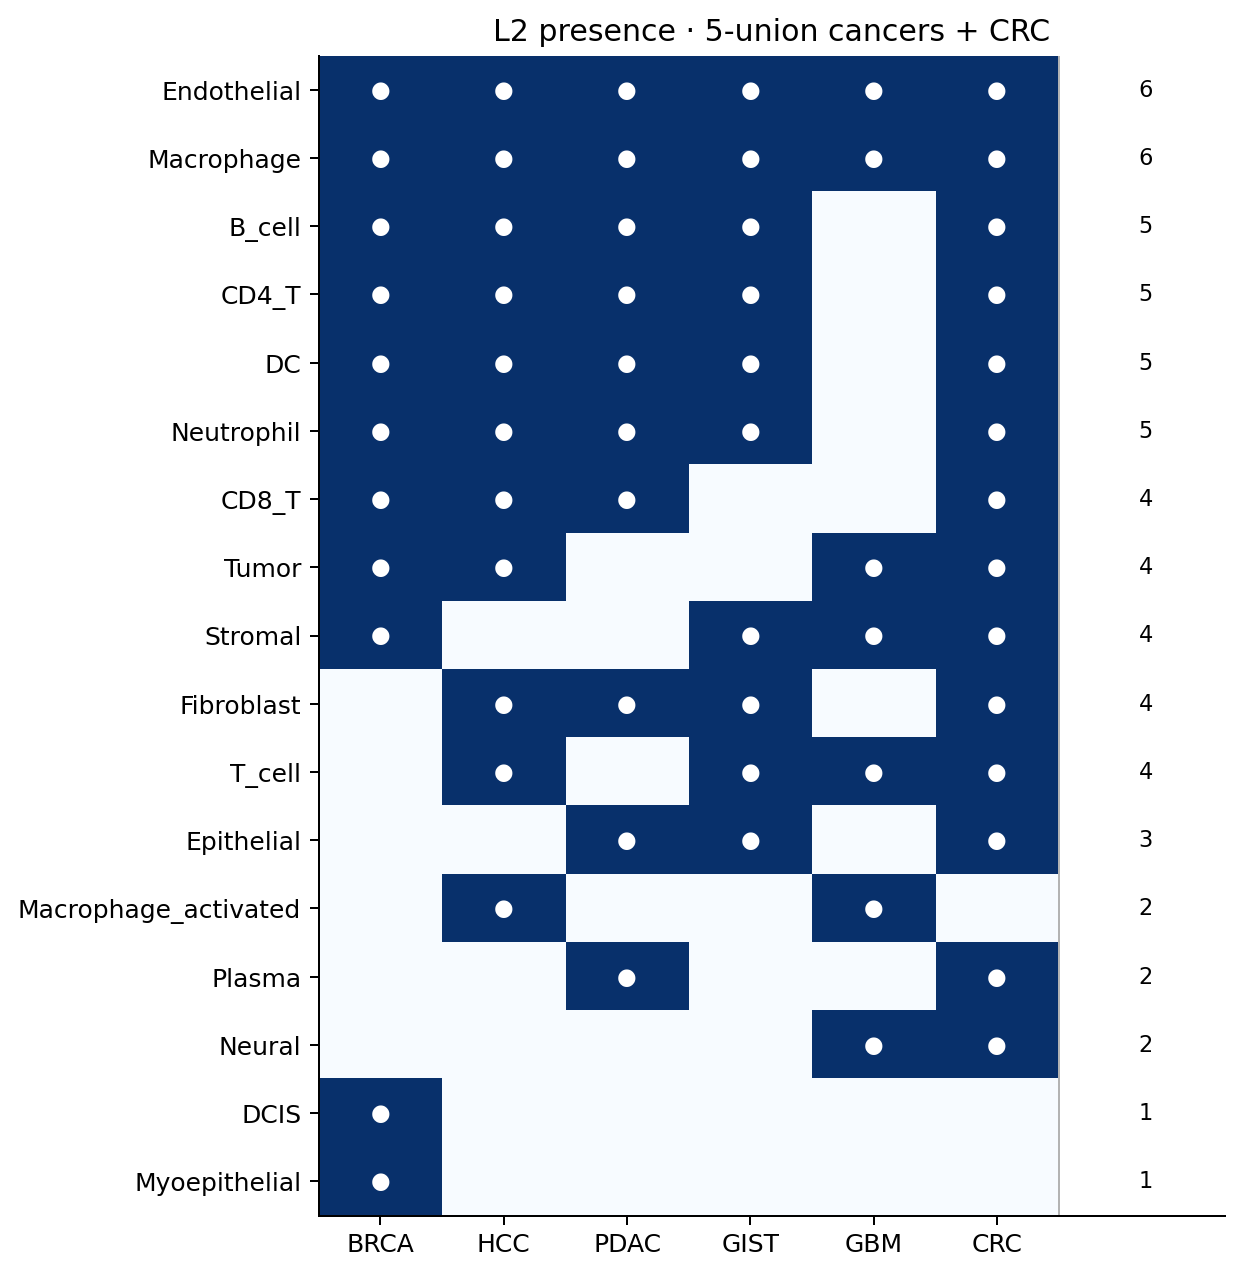

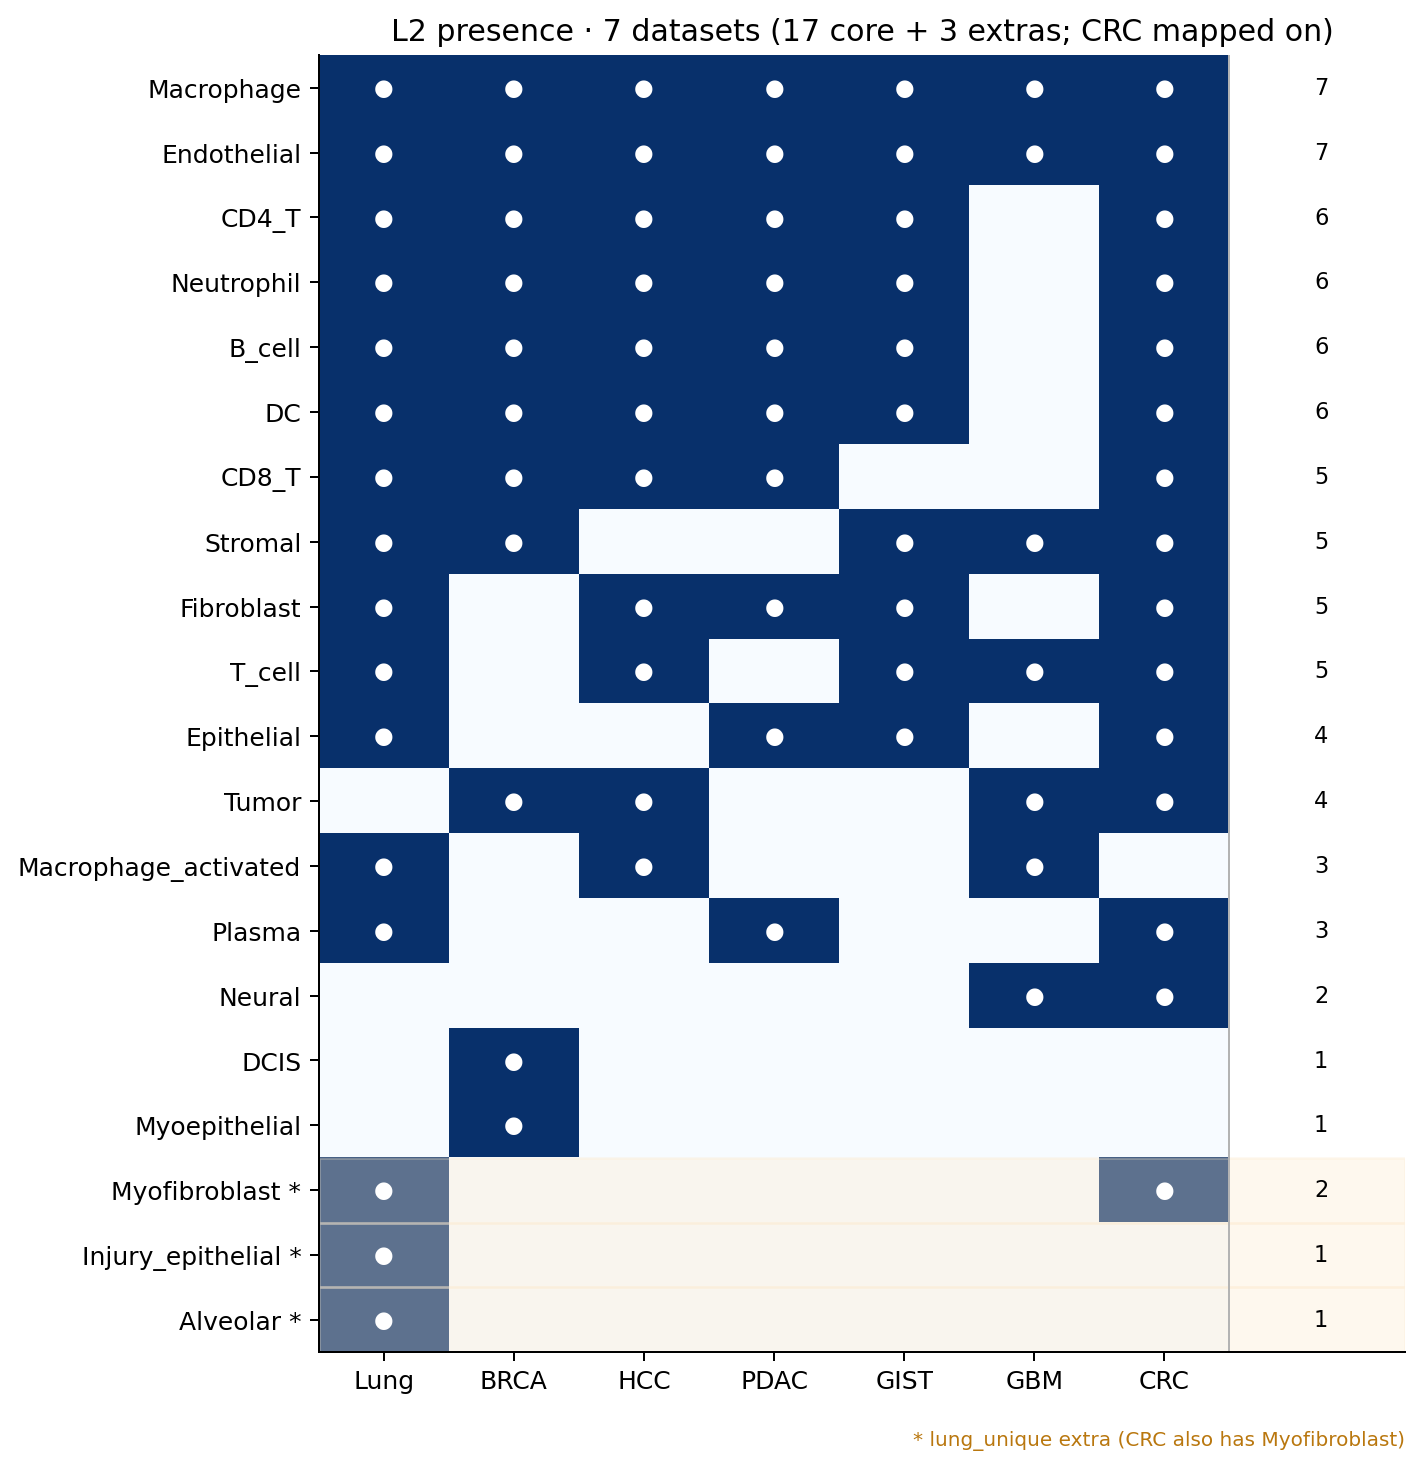

,Lung,BRCA,HCC,PDAC,GIST,GBM,CRC,n_datasets
Macrophage,1,1,1,1,1,1,1,7
Endothelial,1,1,1,1,1,1,1,7
CD4_T,1,1,1,1,1,0,1,6
Neutrophil,1,1,1,1,1,0,1,6
B_cell,1,1,1,1,1,0,1,6
DC,1,1,1,1,1,0,1,6
CD8_T,1,1,1,1,0,0,1,5
Stromal,1,1,0,0,1,1,1,5
Fibroblast,1,0,1,1,1,0,1,5
T_cell,1,0,1,0,1,1,1,5


In [12]:
presence_crc5 = pd.DataFrame(
    {ds: [int(lab in sets_l2[ds]) for lab in sorted(five["union"])] for ds in SIX},
    index=sorted(five["union"]),
)
presence_crc5["n_datasets"] = presence_crc5[SIX].sum(axis=1)
presence_crc5 = presence_crc5.sort_values(
    ["n_datasets"] + SIX, ascending=[False] + [False] * len(SIX)
)
display(presence_crc5)
print("恰好出现在 k 个（五癌+CRC）:")
for k, grp in presence_crc5.groupby("n_datasets"):
    print(f"  k={k} ({len(grp)}): {list(grp.index)}")

fig, ax = plt.subplots(figsize=(7.0, 7.2))
_presence_heatmap(ax, presence_crc5, SIX, "L2 presence · 5-union cancers + CRC")
fig.tight_layout()
fig.savefig(FIG / "06_presence_heatmap_5plus_crc.png", bbox_inches="tight")
plt.show()

labels20 = list(five["union"] | LUNG_UNIQUE)
presence7 = pd.DataFrame(
    {ds: [int(lab in sets_l2[ds]) for lab in labels20] for ds in ALL7},
    index=labels20,
)
presence7["n_datasets"] = presence7[ALL7].sum(axis=1)
presence7["is_extra"] = [lab in LUNG_UNIQUE for lab in presence7.index]
presence7 = presence7.sort_values(
    ["is_extra", "n_datasets"] + ALL7, ascending=[True, False] + [False] * len(ALL7)
)

fig, ax = plt.subplots(figsize=(8.0, 8.2))
_presence_heatmap(
    ax, presence7, ALL7,
    "L2 presence · 7 datasets (17 core + 3 extras; CRC mapped on)",
    extra_rows=LUNG_UNIQUE,
)
ax.text(
    1.0, -0.06, "* lung_unique extra (CRC also has Myofibroblast)",
    transform=ax.transAxes, ha="right", va="top", fontsize=8, color="#b9770e",
)
fig.tight_layout()
fig.savefig(FIG / "06b_presence_heatmap_7datasets.png", bbox_inches="tight")
plt.show()
display(presence7[ALL7 + ["n_datasets"]])


### 9.2 Venn + Jaccard

左：CRC vs 5-union（核心 17）。中：CRC vs BRCA（两个 Xenium 实体瘤）。右：CRC vs Lung（+extras）。


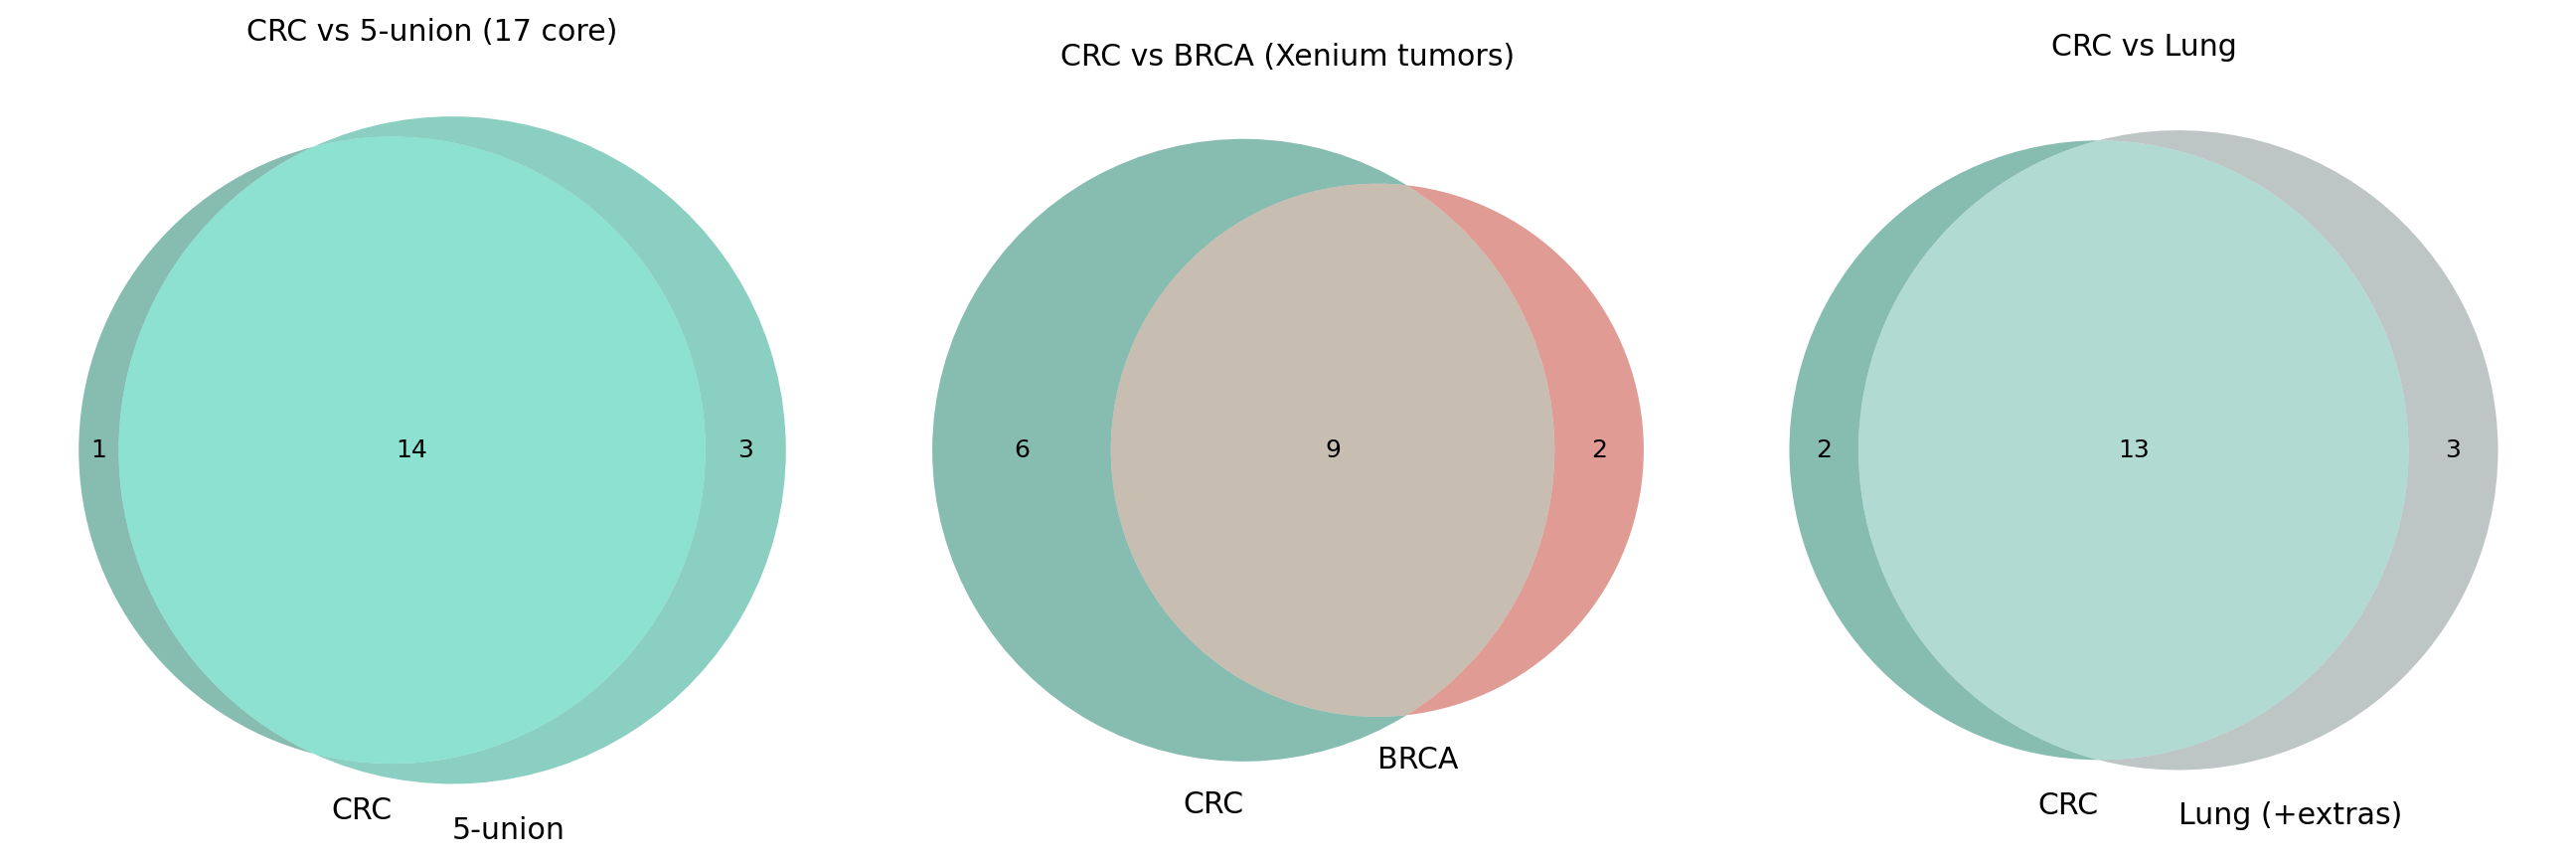

CRC only vs 5-union: ['Myofibroblast']
5-union only vs CRC: ['DCIS', 'Macrophage_activated', 'Myoepithelial']
CRC ∩ BRCA: ['B_cell', 'CD4_T', 'CD8_T', 'DC', 'Endothelial', 'Macrophage', 'Neutrophil', 'Stromal', 'Tumor']
CRC − BRCA: ['Epithelial', 'Fibroblast', 'Myofibroblast', 'Neural', 'Plasma', 'T_cell']
BRCA − CRC: ['DCIS', 'Myoepithelial']
CRC ∩ Lung: ['B_cell', 'CD4_T', 'CD8_T', 'DC', 'Endothelial', 'Epithelial', 'Fibroblast', 'Macrophage', 'Myofibroblast', 'Neutrophil', 'Plasma', 'Stromal', 'T_cell']


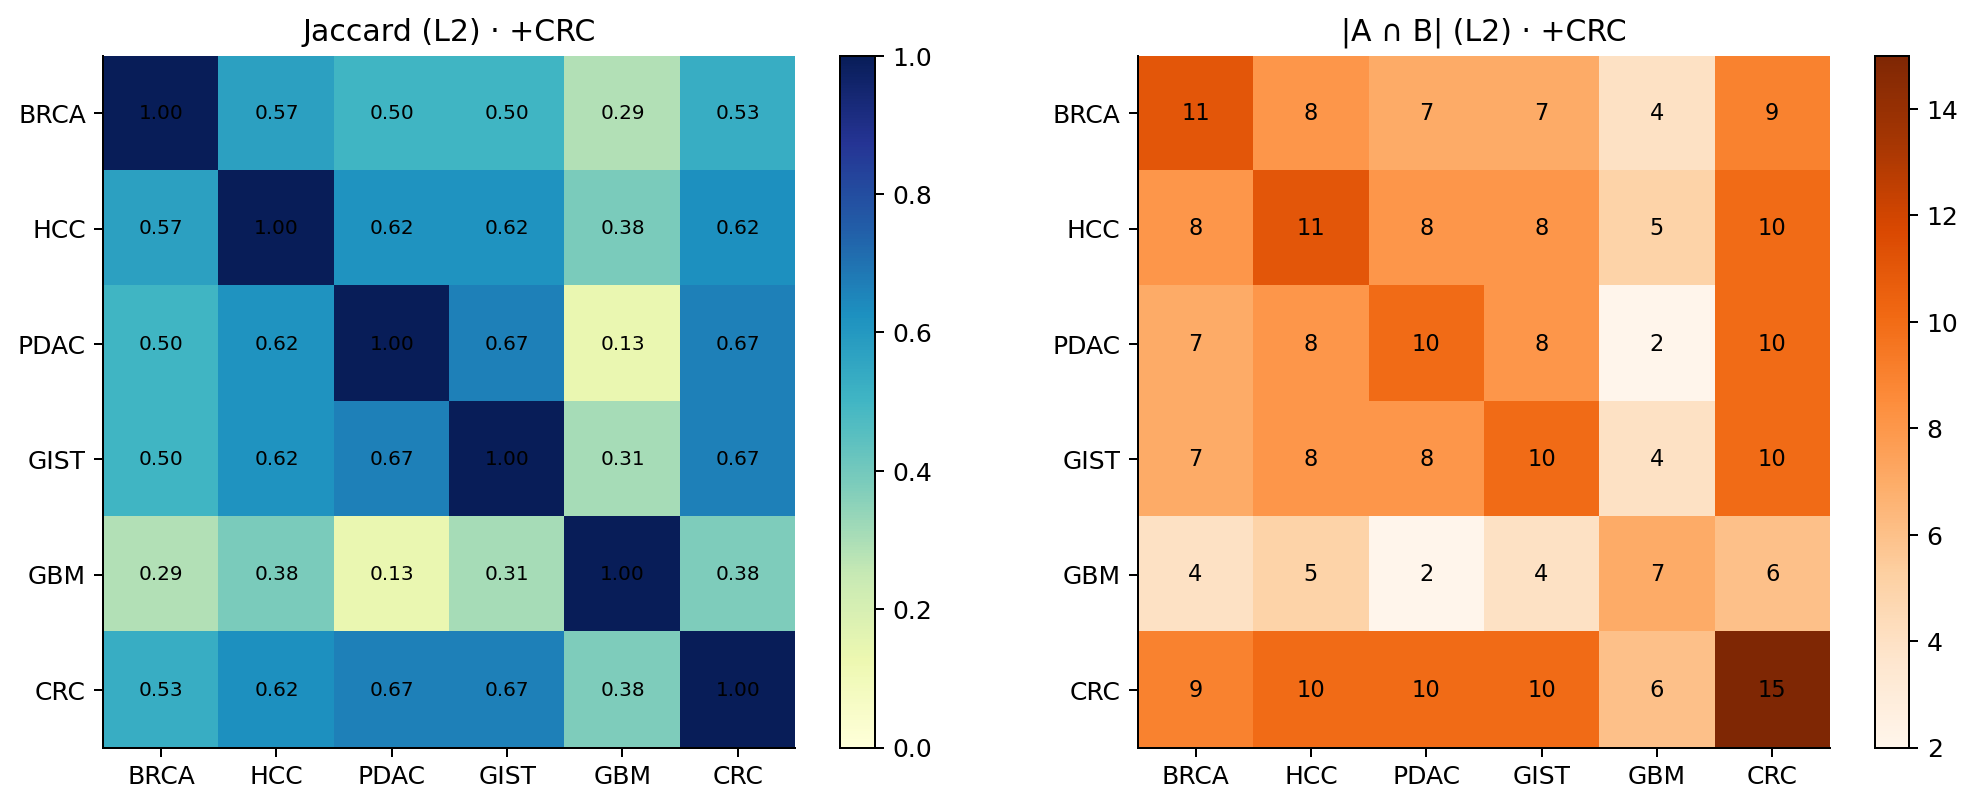

,BRCA,HCC,PDAC,GIST,GBM,CRC
BRCA,11,8,7,7,4,9
HCC,8,11,8,8,5,10
PDAC,7,8,10,8,2,10
GIST,7,8,8,10,4,10
GBM,4,5,2,4,7,6
CRC,9,10,10,10,6,15


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.8))
venn2(
    [sets_l2["CRC"], five["union"]],
    set_labels=("CRC", "5-union"),
    set_colors=(COLORS["CRC"], "#16a085"),
    alpha=0.5,
    ax=axes[0],
)
axes[0].set_title("CRC vs 5-union (17 core)")
venn2(
    [sets_l2["CRC"], sets_l2["BRCA"]],
    set_labels=("CRC", "BRCA"),
    set_colors=(COLORS["CRC"], COLORS["BRCA"]),
    alpha=0.5,
    ax=axes[1],
)
axes[1].set_title("CRC vs BRCA (Xenium tumors)")
venn2(
    [sets_l2["CRC"], sets_l2["Lung"]],
    set_labels=("CRC", "Lung (+extras)"),
    set_colors=(COLORS["CRC"], COLORS["Lung"]),
    alpha=0.5,
    ax=axes[2],
)
axes[2].set_title("CRC vs Lung")
fig.tight_layout()
fig.savefig(FIG / "07_venn2_crc.png", bbox_inches="tight")
plt.show()

print("CRC only vs 5-union:", sorted(sets_l2["CRC"] - five["union"]))
print("5-union only vs CRC:", sorted(five["union"] - sets_l2["CRC"]))
print("CRC ∩ BRCA:", sorted(sets_l2["CRC"] & sets_l2["BRCA"]))
print("CRC − BRCA:", sorted(sets_l2["CRC"] - sets_l2["BRCA"]))
print("BRCA − CRC:", sorted(sets_l2["BRCA"] - sets_l2["CRC"]))
print("CRC ∩ Lung:", sorted(sets_l2["CRC"] & sets_l2["Lung"]))

jacc6 = pd.DataFrame(np.nan, index=SIX, columns=SIX)
overlap6 = pd.DataFrame(0, index=SIX, columns=SIX)
for a, b in combinations(SIX, 2):
    inter = sets_l2[a] & sets_l2[b]
    uni = sets_l2[a] | sets_l2[b]
    j = len(inter) / len(uni) if uni else 0
    jacc6.loc[a, b] = jacc6.loc[b, a] = j
    overlap6.loc[a, b] = overlap6.loc[b, a] = len(inter)
for a in SIX:
    jacc6.loc[a, a] = 1.0
    overlap6.loc[a, a] = len(sets_l2[a])

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.6))
im0 = axes[0].imshow(jacc6.to_numpy(), cmap="YlGnBu", vmin=0, vmax=1)
axes[0].set_xticks(range(len(SIX))); axes[0].set_xticklabels(SIX)
axes[0].set_yticks(range(len(SIX))); axes[0].set_yticklabels(SIX)
axes[0].set_title("Jaccard (L2) · +CRC")
for i in range(len(SIX)):
    for j in range(len(SIX)):
        axes[0].text(j, i, f"{jacc6.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im0, ax=axes[0], fraction=0.046)
im1 = axes[1].imshow(overlap6.to_numpy(), cmap="Oranges")
axes[1].set_xticks(range(len(SIX))); axes[1].set_xticklabels(SIX)
axes[1].set_yticks(range(len(SIX))); axes[1].set_yticklabels(SIX)
axes[1].set_title("|A ∩ B| (L2) · +CRC")
for i in range(len(SIX)):
    for j in range(len(SIX)):
        axes[1].text(j, i, str(int(overlap6.iloc[i, j])), ha="center", va="center", fontsize=9)
fig.colorbar(im1, ax=axes[1], fraction=0.046)
fig.tight_layout()
fig.savefig(FIG / "08_pairwise_jaccard_crc.png", bbox_inches="tight")
plt.show()
display(overlap6)


### 9.3 Native Flex → v1 对照；确认没有新 L2

CRC sheet 的 `celltype_level2` 是 Flex / RCTD Label1；`L2_v1` 是 pan-cancer 训练头。下面按 v1 汇总 native 别名，并核对全局仍是 **17 + 3 = 20**。


In [14]:
crc = sheets["CRC"].copy()
crc = crc[crc.get("trainable_v1", "Y") == "Y"]
crc_map = (
    crc.dropna(subset=["L2_v1"])
    .groupby(["L1_v1", "L12_v1", "L2_v1"], dropna=False)["celltype_level2"]
    .apply(lambda s: "; ".join(sorted({str(x).strip() for x in s if str(x).strip() and str(x) != "Unlabeled"})))
    .reset_index()
    .rename(columns={"L1_v1": "L1", "L12_v1": "L12", "L2_v1": "L2", "celltype_level2": "Flex_native"})
)
crc_map["in_5union"] = crc_map["L2"].map(lambda x: "Y" if x in five["union"] else "N")
crc_map["l2_scope"] = crc_map["L2"].map(lambda x: "lung_unique" if x in LUNG_UNIQUE else "core_5union")
display(crc_map.sort_values(["L1", "L12", "L2"]).reset_index(drop=True))

ct_sheet = pd.read_excel(XLSX, "celltype")
train = ct_sheet[ct_sheet["trainable"] == "Y"]
crc_present = train[train["present_in"].fillna("").str.contains("CRC")][["L1", "L12", "L2", "l2_scope", "present_in"]]
display(crc_present.reset_index(drop=True))

new_l2 = sets_l2["CRC"] - (five["union"] | LUNG_UNIQUE)
print("trainable L2 still", len(train), "(期望 20)")
print("CRC 是否引入新 v1 L2:", sorted(new_l2) or "(none)")
assert not new_l2, new_l2
assert set(train["L2"]) == five["union"] | LUNG_UNIQUE
print("OK: CRC mapped onto existing 20-class ontology; no new L2")
print("figures →", FIG)
print("  06_presence_heatmap_5plus_crc.png")
print("  06b_presence_heatmap_7datasets.png")
print("  07_venn2_crc.png")
print("  08_pairwise_jaccard_crc.png")


,L1,L12,L2,Flex_native,in_5union,l2_scope
0,Endothelial,Endothelial,Endothelial,Endothelial; Lymphatic Endothelial,Y,core_5union
1,Epithelial,Epithelial,Epithelial,Enterocyte; Goblet; Neuroendocrine; Tuft,Y,core_5union
2,Epithelial,Tumor,Tumor,Tumor I; Tumor II; Tumor III; Tumor IV; Tumor V,Y,core_5union
3,Immune,B_Plasma,B_cell,Mature B; Memory B; Proliferating Immune II,Y,core_5union
4,Immune,B_Plasma,Plasma,Plasma,Y,core_5union
5,Immune,Myeloid,DC,cDC I; mRegDC; pDC,Y,core_5union
6,Immune,Myeloid,Macrophage,Macrophage; Proliferating Macrophages,Y,core_5union
7,Immune,Myeloid,Neutrophil,Mast; Neutrophil,Y,core_5union
8,Immune,T_cell,CD4_T,CD4 T cell,Y,core_5union
9,Immune,T_cell,CD8_T,CD8 T cell,Y,core_5union


,L1,L12,L2,l2_scope,present_in
0,Epithelial,Tumor,Tumor,core_5union,BRCA; HCC; GBM; CRC
1,Epithelial,Epithelial,Epithelial,core_5union,Lung; PDAC; GIST; CRC
2,Immune,T_cell,CD4_T,core_5union,Lung; BRCA; HCC; PDAC; GIST; CRC
3,Immune,T_cell,CD8_T,core_5union,Lung; BRCA; HCC; PDAC; CRC
4,Immune,T_cell,T_cell,core_5union,Lung; HCC; GIST; GBM; CRC
5,Immune,B_Plasma,B_cell,core_5union,Lung; BRCA; HCC; PDAC; GIST; CRC
6,Immune,B_Plasma,Plasma,core_5union,Lung; PDAC; CRC
7,Immune,Myeloid,DC,core_5union,Lung; BRCA; HCC; PDAC; GIST; CRC
8,Immune,Myeloid,Macrophage,core_5union,Lung; BRCA; HCC; PDAC; GIST; GBM; CRC
9,Immune,Myeloid,Neutrophil,core_5union,Lung; BRCA; HCC; PDAC; GIST; CRC


trainable L2 still 20 (期望 20)
CRC 是否引入新 v1 L2: (none)
OK: CRC mapped onto existing 20-class ontology; no new L2
figures → /nobackup2/users/lingyu/Python/Hist2Pheno/code/Hist2Pheno_pkg/dataset/figures_l2_overlap
  06_presence_heatmap_5plus_crc.png
  06b_presence_heatmap_7datasets.png
  07_venn2_crc.png
  08_pairwise_jaccard_crc.png
